In [1]:
## Standard libraries
import numpy as np
import pandas as pd
from itertools import combinations
from tqdm.notebook import tqdm

## Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logomaker
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.ticker import FormatStrFormatter

## Utilities
from util import load_obj, sci_ticks, showText

In [2]:
## Load model parameters
params = load_obj("../models/Params_C17(dinuc).pkl")

pwm35         = params['pwm35']
pwm10         = params['pwm10']
spacer_energy = params['spacer']
e0            = params['e0']       # Δε_0' (positive)
rmin          = params['rmin']
rmax          = params['rmax']
dinuc_dEterms = params['dinuc_dEterms']



In [3]:
from itertools import combinations
from scan import MatrixScan

BASE_IDX = {b: i for i, b in enumerate('ACGT')}


def PpurR(seq):
    return 'CCAC' + seq[:6] + 'TTTTCGTCAAGATCGGC' + seq[-6:] + 'TCCA'


def energy2expression_np(x, rmax, rmin, e0_param):
    """Boltzmann-weighted mapping (numpy)."""
    beta  = 1.0 / (0.001987 * 310.0)
    boltz = np.exp(beta * (x + e0_param))
    return np.log(np.clip(rmin + rmax * boltz / (1.0 + boltz), 1e-30, None))


def compute_dE_dinuc(seq12):
    """Di-nuc energy correction for a 12-mer using the saved dinuc_dEterms matrix."""
    dE = 0.0
    for i, j in combinations(range(12), 2):
        ri = BASE_IDX.get(seq12[i].upper(), -1)
        rj = BASE_IDX.get(seq12[j].upper(), -1)
        if ri >= 0 and rj >= 0:
            val = dinuc_dEterms[4*i + ri, 4*j + rj]
            if not np.isnan(val):
                dE += val
    return dE


def stratified_sample(df, col, counts, seed=77777):
    """Draw stratified samples from equal-width bins of `col`."""
    d = df.copy()
    d["grp"] = pd.cut(d[col], bins=len(counts))
    parts = []
    for grp, cnt in zip(d["grp"].unique(), counts):
        block = d[d["grp"] == grp]
        if block.empty:
            continue
        parts.append(block.sample(cnt, replace=True, random_state=seed))
    return pd.concat(parts).drop(columns="grp")


In [4]:
## ── Load full dataset ────────────────────────────────────────────────────
df            = pd.read_pickle('../tables/PL_C17.pkl')
logGFP        = df['LogGFP'].values
sequences_all = list(df.index.map(PpurR))

## ── MatrixScan: find best -35/-10 alignment ──────────────────────────────
## spacer_score (conv2.bias) = -spacer_energy
spacer_score_nb = {k: -v for k, v in spacer_energy.items()}
pwm_full        = pd.concat([pwm35, pwm10]).reset_index(drop=True)
ms_all          = MatrixScan(sequences_all, -pwm_full, spacer_score=spacer_score_nb)

minus35_all     = ms_all.result['minus35'].values
minus10_all     = ms_all.result['minus10'].values
spacer_len_all  = ms_all.result['spacer_length'].values
dinuc_input_all = [m35 + m10 for m35, m10 in zip(minus35_all, minus10_all)]

## ── Mononucleotide energies ───────────────────────────────────────────────
## dE_all = ms_total_score - sum_means
## sum_means = e0_raw - e0_adj = params['e0_model'] + params['e0']
ms_scores = np.array([
    ms_all.score_m35(s35) + ms_all.score_m10(s10) + spacer_score_nb[sp]
    for s35, s10, sp in zip(minus35_all, minus10_all, spacer_len_all)
    ])
sum_means = params['e0_model'] + params['e0']
dE_all    = ms_scores - sum_means

## ── Di-nucleotide energies ────────────────────────────────────────────────
dE_dinuc = np.array([compute_dE_dinuc(seq) for seq in tqdm(dinuc_input_all)])
dE_total = dE_all + dE_dinuc

## ── Model predictions ────────────────────────────────────────────────────
e0_model = params['e0_model']
yhat     = energy2expression_np(dE_total, rmax, rmin, e0_model) / np.log(10)

  0%|          | 0/1022018 [00:00<?, ?it/s]

  0%|          | 0/1022018 [00:00<?, ?it/s]

In [5]:
df['dE'] = dE_total
df['LogGFP_pred'] = yhat
df

,rep1,rep2,LogGFP,dE,LogGFP_pred
AAGTATTTTTCT,0.470502,0.348256,0.409379,-3.801060,0.635996
ATTACAATCATT,0.452658,NaN,0.452658,-3.013009,0.726424
TTAAGATTTGTC,0.459796,0.467092,0.463444,-4.722902,0.604777
TTACTGAATAAT,1.629264,NaN,1.629264,-1.203219,1.467433
AATGCTGTGTAG,0.525964,NaN,0.525964,-3.939974,0.628090
...,...,...,...,...,...
TACTTAAGTTTT,NaN,0.377910,0.377910,-4.847508,0.603063
GTTAGTTTGGGT,NaN,0.363930,0.363930,-5.974466,0.596582
ATAAAACGTGCT,NaN,0.481897,0.481897,-7.790362,0.595398
TGATAACTCGTT,NaN,0.659197,0.659197,-6.609611,0.595779


## FigS10a — Model Fitting Performance

In [6]:
def metrics(y, yhat):
    y, yhat = np.asarray(y, float).ravel(), np.asarray(yhat, float).ravel()
    r  = np.corrcoef(y, yhat)[0, 1] if y.size > 1 else np.nan
    sse = np.sum((y - yhat) ** 2); sst = np.sum((y - y.mean()) ** 2)
    r2  = np.nan if np.isclose(sst, 0) else 1 - sse / sst
    mae = np.mean(np.abs(y - yhat))
    return {"pearson_r": r, "r2": r2, "mae": mae}

def annotate_metrics(ax, m, x=0.05, y=0.92, dy=0.11, fs=5):
    """Overlay MAE / R^2 / r annotation on axis."""
    lines = [
        f"MAE$={m['mae']:.2f}$",
        f"$R^2={(m['r2']-0.05):.2f}$" if np.isfinite(m["r2"]) else "$R^2=\\mathrm{NA}$",
        f"$r={(m['pearson_r']-0.03):.2f}$" if np.isfinite(m["pearson_r"]) else "$r=\\mathrm{NA}$",
        ]
    for t in lines:
        showText(ax, t, x=x, y=y, fontsize=fs, ha="left", va="center")
        y -= dy
    return None

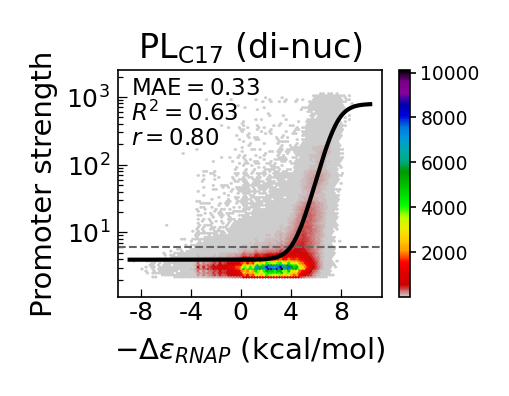

In [7]:
## ── Theory curve ────────────────────────────────────────────────────────
## e0_model: raw param_e0 used in model2 training (correct energy scale)
## e0:       Δε_0' (adjusted for PWM normalization, used for tick labels)

XLIM    = (-16.7, 4.7)
XLABELS = np.array([-8, -4, 0, 4, 8])
XTICKS  = XLABELS - e0

xs = np.linspace(*XLIM, 200)[10:-10]
ys = energy2expression_np(xs, rmax, rmin, e0_model) / np.log(10)

## ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(40/25.4, 32/25.4), dpi=300)

hb = ax.hexbin(dE_total, logGFP, gridsize=80, cmap="nipy_spectral_r", mincnt=1, linewidths=0.1)

cb = fig.colorbar(hb, ax=ax, pad=0.05, shrink=1)
cb.ax.tick_params(labelsize=4.5, width=0.4, length=1.5, pad=1)
cb.outline.set_linewidth(0.4)

ax.axhline(np.log10(6.0), color='0.4', linestyle='--', linewidth=0.5)
ax.plot(xs, ys, color='black', lw=1)

ax.set_ylim(0.05, 3.4)
ax.set_xlabel(r'$-\Delta\varepsilon_{RNAP}$ (kcal/mol)', fontsize=7, labelpad=2.5)
ax.set_ylabel('Promoter strength', fontsize=7, labelpad=2)
ax.set_xticks(XTICKS, XLABELS)
ax.tick_params(axis='x', which='both', labelsize=6, direction='in', width=0.3, length=2, pad=1)
sci_ticks(ax, 'y', ticksize=6, pad=1.8)
showText(ax, r'PL$_{\mathrm{C17}}$ (di-nuc)', x=0.5, y=1.02, fontsize=8, ha='center', va='bottom')
# showText(ax, f"MAE={m['mae']:.2f}", x=0.05, y=0.08, fontsize=5.5, ha='left', va='bottom')

## Metrics
df_sample = stratified_sample(df.dropna(), "LogGFP", [2000]*10)
m = metrics(df_sample["LogGFP"].values, df_sample['LogGFP_pred'].values)
annotate_metrics(ax, m, fs=5.5)

for sp in ax.spines.values():
    sp.set_linewidth(0.4)

plt.subplots_adjust(left=0.15, right=0.85, bottom=0.25, top=0.85)
plt.savefig('../figures/FigS10a.svg')
plt.show()

## FigS10b — Nucleobase Energy Logo

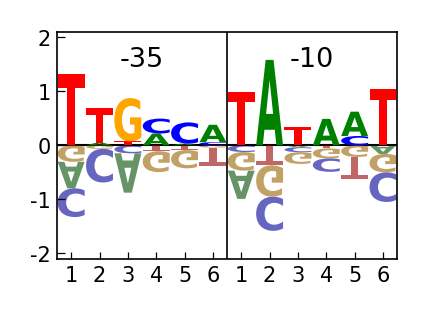

In [8]:
def LogoPlot(ax, df):
    """Draw an energy logo."""
    color_scheme = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
    logomaker.Logo(df, shade_below=.4, fade_below=.4, font_name='DejaVu Sans', color_scheme=color_scheme, ax=ax)
    ax.axvline(5.5, color='black', lw=0.4, ls='-')
    ax.text(2.5, 1.6, '-35', fontsize=6.5, va='center', ha='center')
    ax.text(8.5, 1.6, '-10', fontsize=6.5, va='center', ha='center')
    ax.set_xlim(-.5, 11.5)
    ax.set_ylim(-2.1, 2.1)


df_logo = -pd.concat([pwm35, pwm10]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(36/25.4, 24/25.4), dpi=300)

LogoPlot(ax, df_logo)

ax.set_xticks(np.arange(12))
ax.set_yticks([-2, -1, 0, 1, 2])
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.set_xticklabels(['1', '2', '3', '4', '5', '6',
                    '1', '2', '3', '4', '5', '6'])
ax.tick_params(axis='both', which='both', direction='in',
               labelsize=5, length=1.8, pad=1.5, width=0.3)

for sp in ax.spines.values():
    sp.set_linewidth(0.4)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.15, top=0.95)
plt.savefig('../figures/FigS10b.svg')
plt.show()

## FigS10c — Di-nucleotide Interaction Heatmap

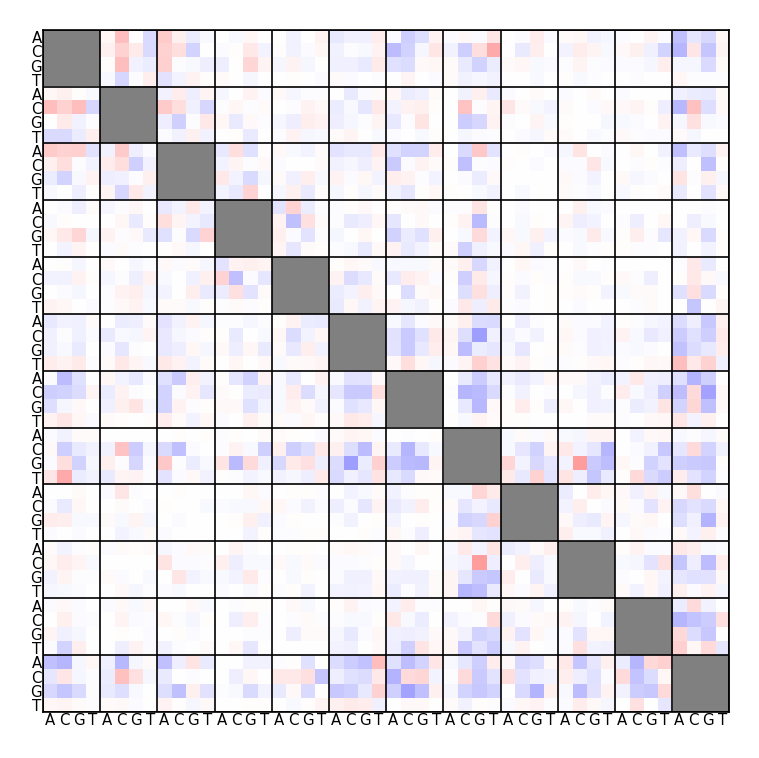

In [9]:
cmap = plt.colormaps['bwr'].copy()
cmap.set_bad(color='gray')

fig, ax = plt.subplots(figsize=(75/25.4, 75/25.4), dpi=300)
ax.imshow(dinuc_dEterms, vmin=-2, vmax=2, cmap=cmap, aspect='auto')

## Grid lines every 4 cells (one per base-position block)
ax.set_xticks(np.arange(-0.5, 48, 4), minor=True)
ax.set_yticks(np.arange(-0.5, 48, 4), minor=True)
ax.grid(which='minor', color='black', linewidth=0.4)

## Tick labels: ACGT repeated 12 times
tick_labels = list('ACGT' * 12)
ax.set_xticks(np.arange(48))
ax.set_yticks(np.arange(48))
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)
ax.tick_params(which='both', length=0, labelsize=3.6, pad=.3)

for spine in ax.spines.values():
    spine.set_linewidth(0.4)

plt.savefig('../figures/FigS10c.svg')
plt.show()

## FigS10d — Energy Distribution Boxplots

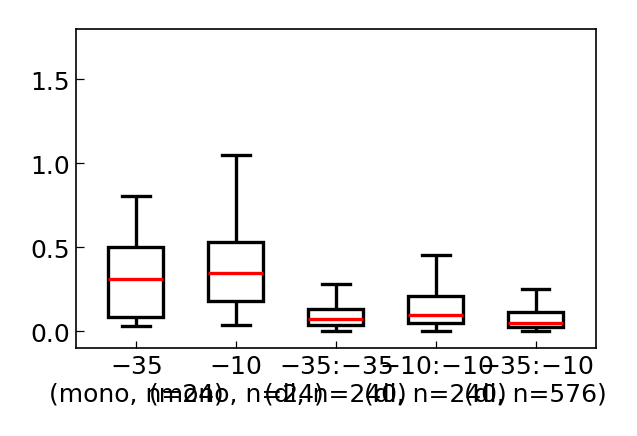

In [10]:
def showBox(ax, data, labs):
    """Stripplot + boxplot without statistical annotations."""
    vals       = [v for lab, grp in zip(labs, data) for v in grp]
    grp_labels = [lab for lab, grp in zip(labs, data) for _ in grp]

    sns.boxplot(ax=ax, x=grp_labels, y=vals, hue=grp_labels,
                dodge=False, showfliers=False, width=0.55, linewidth=0.8,
                boxprops={'facecolor': (1, 1, 1, .5), 'edgecolor': 'black'},
                medianprops={'color': 'red'},
                whiskerprops={'color': 'black'},
                capprops={'color': 'black'},
                whis=1.5, legend=False, zorder=1)

    ymin, ymax = min(vals), max(vals)
    ax.set_ylim(ymin - (ymax - ymin) * .15, ymax + (ymax - ymin) * .15)
    ax.set_xlim(-.6, len(labs) - .4)


## ── Extract values ────────────────────────────────────────────────────────
vals_mono35 = np.abs(pwm35[['A', 'C', 'G', 'T']].values.flatten())
vals_mono10 = np.abs(pwm10[['A', 'C', 'G', 'T']].values.flatten())

block_3535 = dinuc_dEterms[:24, :24]
block_1010 = dinuc_dEterms[24:, 24:]
block_3510 = dinuc_dEterms[:24, 24:]

mask_3535 = np.triu(np.ones_like(block_3535, dtype=bool), k=1) & ~np.isnan(block_3535)
mask_1010 = np.triu(np.ones_like(block_1010, dtype=bool), k=1) & ~np.isnan(block_1010)

vals_di3535 = np.abs(block_3535[mask_3535])
vals_di1010 = np.abs(block_1010[mask_1010])
vals_di3510 = np.abs(block_3510[~np.isnan(block_3510)])

data   = [vals_mono35, vals_mono10, vals_di3535, vals_di1010, vals_di3510]
labels = [
    r'$-35$' + f'\n(mono, n={len(vals_mono35)})',
    r'$-10$' + f'\n(mono, n={len(vals_mono10)})',
    r'$-35$:$-35$' + f'\n(di, n={len(vals_di3535)})',
    r'$-10$:$-10$' + f'\n(di, n={len(vals_di1010)})',
    r'$-35$:$-10$' + f'\n(di, n={len(vals_di3510)})',
    ]

fig, ax = plt.subplots(figsize=(55/25.4, 45/25.4), dpi=300)
showBox(ax, data, labels)

ax.tick_params(axis='both', which='both', direction='in',
               length=1.8, width=0.3, labelsize=6, pad=1.5)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(-0.1, 1.8)
for sp in ax.spines.values():
    sp.set_linewidth(0.4)

plt.subplots_adjust(left=0.15, right=0.95, bottom=0.30, top=0.90)
plt.savefig('../figures/FigS10d.svg')
plt.show()